In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import calculate_F1
%load_ext autoreload
%autoreload 2

In [4]:
train_data = pd.read_csv('Data/train.csv', index_col='id')
test_data = pd.read_csv('Data/test.csv' , index_col='id')

In [5]:
X = train_data.drop('Heart Disease', axis=1)
y = train_data['Heart Disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
rf = RandomForestClassifier(random_state=42)
gridsearch = GridSearchCV(rf, param_grid={
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30]}, cv=2, n_jobs=-1)
gridsearch.fit(X_train, y_train)
print("Best parameters:", gridsearch.best_params_)

KeyboardInterrupt: 

In [ ]:
best_rf = RandomForestClassifier(random_state=42, **gridsearch.best_params_)

In [ ]:
calculate_F1(X_train, y_train, X_test, y_test, interval=np.arange(10, 100, 10))

KeyboardInterrupt: 

              precision    recall  f1-score   support

     Absence       0.89      0.90      0.89     69564
    Presence       0.87      0.86      0.87     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



Text(0.5, 23.52222222222222, 'Predicted')

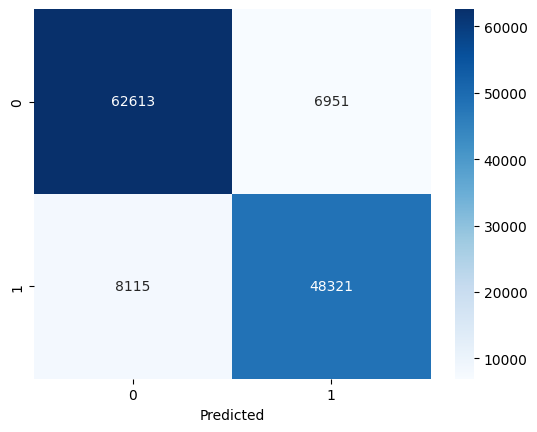

In [ ]:
rf_nodes = RandomForestClassifier(max_leaf_nodes=85, random_state=42)
rf_nodes.fit(X_train, y_train)
y_pred_n = rf_nodes.predict(X_test)
print(classification_report(y_test, y_pred_n))
cm = confusion_matrix(y_test, y_pred_n)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')


              precision    recall  f1-score   support

     Absence       0.89      0.90      0.90     69564
    Presence       0.88      0.86      0.87     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



Text(0.5, 23.52222222222222, 'Predicted')

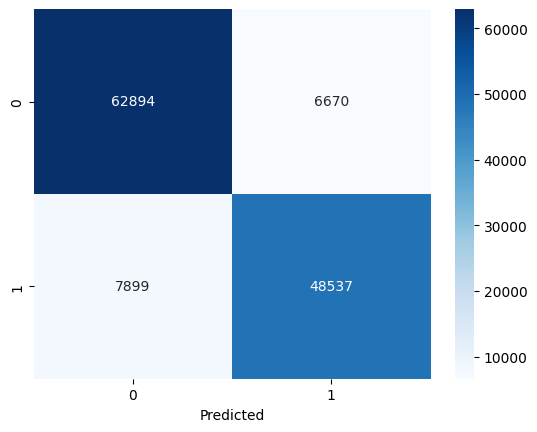

In [ ]:
best_rf.fit(X_train, y_train)
best_rf.predict(X_test)
y_pred = best_rf.predict(X_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')


In [ ]:
pipeline = make_pipeline(StandardScaler(),
                         MLPClassifier(hidden_layer_sizes=(100,50,25,12,6,3),
                                       activation='tanh',
                                       solver='sgd',
                                       random_state=42))
pipeline.fit(X_train, y_train)
y_pred_nn = pipeline.predict(X_test)
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

     Absence       0.88      0.91      0.90     69564
    Presence       0.88      0.85      0.87     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



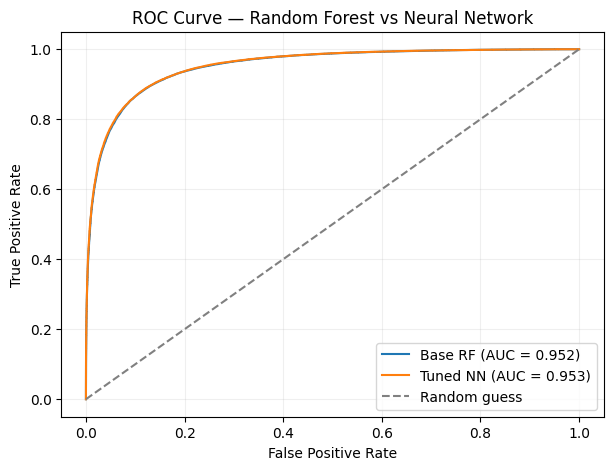

In [ ]:
y_train_bin = y_train.map({'Presence': 1, 'Absence': 0})
y_test_bin  = y_test.map({'Presence': 1, 'Absence': 0})

y_proba_rf_best = best_rf.predict_proba(X_test)[:, 1]
y_proba_nn = pipeline.predict_proba(X_test)[:, 1]

fpr_base, tpr_base, _ = roc_curve(y_test_bin, y_proba_rf_best)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test_bin, y_proba_nn)

auc_base = roc_auc_score(y_test_bin, y_proba_rf_best)
auc_tuned = roc_auc_score(y_test_bin, y_proba_nn)

plt.figure(figsize=(7, 5))
plt.plot(fpr_base, tpr_base, label=f'Base RF (AUC = {auc_base:.3f})')
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned NN (AUC = {auc_tuned:.3f})')
plt.plot([0, 1], [0, 1], '--', color='grey', label='Random guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest vs Neural Network')
plt.legend()
plt.grid(alpha=0.2)
plt.show()